# Capse.jl Chains

In this notebook we will show how to use the Capse.jl emulator in combination with Turing.jl, performing a Planck lite analysis. In particular, we are gonna show:

- How to compute the Maximum A Posteriori (MAP), using the L-BFGS method provided by Optim.jl
- How to use Pathfinder.jl to obtain a quick posterior estimate and initialize chains
- How to use NUTS and MicroCanonical Hamiltonian MonteCarlo as sampling algorithms

Let us start activating the Julia environment and loading any relevent packages

In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Desktop/Waterloo/Masters/JulaiLocalEnv`


In [2]:
Pkg.instantiate()
Pkg.resolve()

  No Changes to `~/Desktop/Waterloo/Masters/JulaiLocalEnv/Project.toml`
  No Changes to `~/Desktop/Waterloo/Masters/JulaiLocalEnv/Manifest.toml`


In [3]:
using Turing
using Capse
#using NPZ
using PlanckLite
using BenchmarkTools
using Plots
using Optim
using ForwardDiff
#using LinearAlgebra
using Pathfinder
#using MicroCanonicalHMC
#using Transducers
using StatsPlots
#using PairPlots
#using LaTeXStrings
#using CairoMakie
using MCMCChains
include("utils.jl");
     

compute_ESS_s (generic function with 1 method)

Initialize our trained emulators

In [4]:
CℓTT_emu = Capse.load_emulator("/Users/ethansmith/Desktop/Waterloo/Masters/JulaiLocalEnv/trained_emu/TT"; emu = Capse.LuxEmulator);
CℓTE_emu = Capse.load_emulator("/Users/ethansmith/Desktop/Waterloo/Masters/JulaiLocalEnv/trained_emu/TE"; emu = Capse.LuxEmulator);
CℓEE_emu = Capse.load_emulator("/Users/ethansmith/Desktop/Waterloo/Masters/JulaiLocalEnv/trained_emu/EE"; emu = Capse.LuxEmulator);

After instantiating our emulator(s), we can retrieve some informations about it

In [5]:
Capse.get_emulator_description(CℓTT_emu)


The parameters the model has been trained are, in the following order: ln10As, ns, H0, ωb, ωc, τ.
The emulator has been trained by Marco Bonici.
Marco Bonici email is bonici.marco@gmail.com.
The emulator has been trained on the high-precision-settings prediction as computed by the CAMB Boltzmann solver.


Let us benchmark Capse.jl against some random input

In [6]:
x = rand(6)
y1 = Capse.get_Cℓ(x, CℓTT_emu) #let us save the output
@benchmark Capse.get_Cℓ(x, CℓTT_emu)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  47.958 μs …  10.517 ms  ┊ GC (min … max):  0.00% … 99.27%
 Time  (median):     57.417 μs               ┊ GC (median):     0.00%
 Time  (mean ± σ):   68.304 μs ± 193.623 μs  ┊ GC (mean ± σ):  12.94% ±  7.22%

       ▁█▃▂▁                                                    
  ▆▃▂▂▃█████▇▅▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▂▂▁▁▁▁▁▁▁▂▂▁▂▁▂▁▂▂▂ ▃
  48 μs           Histogram: frequency by time          120 μs <

 Memory estimate: 260.34 KiB, allocs estimate: 52.

We can also use SimpleChains.jl as a backend

In [7]:
CℓTT_emu = Capse.load_emulator("/Users/ethansmith/Desktop/Waterloo/Masters/JulaiLocalEnv/trained_emu/TT"; emu = Capse.LuxEmulator);
y2 = Capse.get_Cℓ(x, CℓTT_emu)
@benchmark Capse.get_Cℓ(x,CℓTT_emu)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  48.000 μs …  10.476 ms  ┊ GC (min … max):  0.00% … 99.28%
 Time  (median):     57.542 μs               ┊ GC (median):     0.00%
 Time  (mean ± σ):   68.217 μs ± 205.261 μs  ┊ GC (mean ± σ):  14.52% ±  7.15%

  ▂         ▄▂▁▅█▃▆▄▂▂▃                                         
  █▇▂▂▂▂▂▂▂▂███████████▇▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▃
  48 μs           Histogram: frequency by time         82.3 μs <

 Memory estimate: 260.34 KiB, allocs estimate: 52.

We can check that the two backends output matches

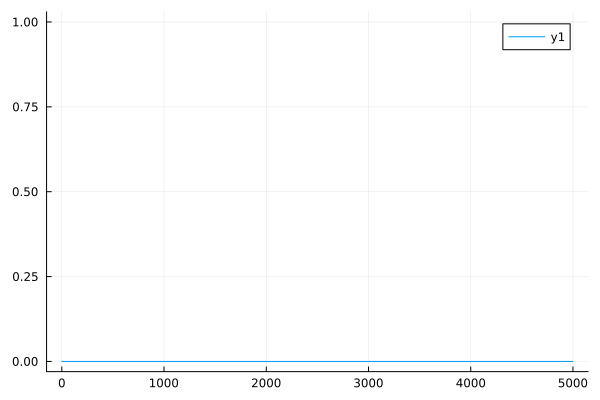

In [8]:
Plots.plot(y1 .- y2)

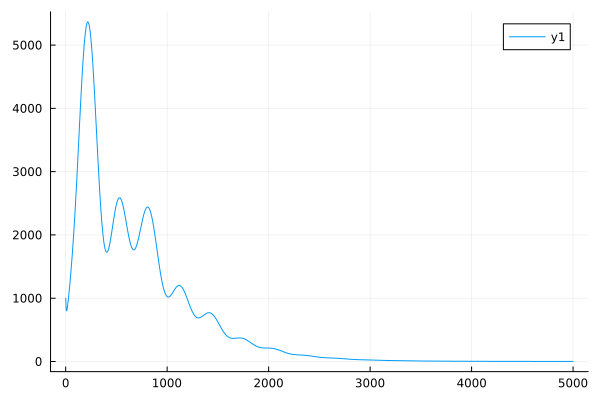

In [9]:
Plots.plot(Capse.get_Cℓ([3, 0.96, 67, 0.02, 0.12, 0.05], CℓTT_emu))

## PlanckLite and Turing

Here we are going to create some functions to analyze Planck data. The first function, given a list of arguments, retrieves the binned 
C<sub>l</sub>'s

In [10]:
lsTT = 2:2508
lsTE = 2:1996
facTT=lsTT.*(lsTT.+1)./(2*π)
facTE=lsTE.*(lsTE.+1)./(2*π)

function call_emu_planck(θ, Emu_TT, Emu_TE, Emu_EE, facTT, facTE)
    return PlanckLite.bin_Cℓ(Capse.get_Cℓ(θ, Emu_TT)[1:2507]./facTT,
                            Capse.get_Cℓ(θ, Emu_TE)[1:1995]./facTE,
                            Capse.get_Cℓ(θ, Emu_EE)[1:1995]./facTE)
end

call_emu_planck (generic function with 1 method)

This other function is a closure, defining a more manageable version of the same function (in this way we don't have to pass some fixed arguments)

In [11]:
theory_planck(θ) = call_emu_planck(θ, CℓTT_emu, CℓTE_emu, CℓEE_emu, facTT, facTE)

theory_planck (generic function with 1 method)

Let us now define a dummy scalar function (i.e. a function $R^n$ -> $R^1$), that we are gonna use as a benchmark to evaluate gradients

In [12]:
@benchmark theory_planck($x)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  170.667 μs …  18.981 ms  ┊ GC (min … max):  0.00% … 98.60%
 Time  (median):     197.458 μs               ┊ GC (median):     0.00%
 Time  (mean ± σ):   234.968 μs ± 325.795 μs  ┊ GC (mean ± σ):  15.30% ± 14.97%

  ▆▇█▅▄▂▁                                                ▁▁     ▂
  ███████▇▅▄▁▄▃▁▄▄▁▃▃▄▁▁▁▃▃▁▃▃▁▁▁▁▁▁▃▁▃▁▁▁▁▁▁▃▁▃▁▃▁▁▁▁▅▇█████▇▆ █
  171 μs        Histogram: log(frequency) by time        944 μs <

 Memory estimate: 895.61 KiB, allocs estimate: 186.

In [13]:
mytest(x) = sum(abs2, theory_planck(x))

mytest (generic function with 1 method)

In [14]:
@benchmark (mytest($x))

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  171.208 μs …  20.775 ms  ┊ GC (min … max):  0.00% … 98.56%
 Time  (median):     202.292 μs               ┊ GC (median):     0.00%
 Time  (mean ± σ):   258.077 μs ± 424.721 μs  ┊ GC (mean ± σ):  17.05% ± 14.83%

  ▆█▆▄▁▁                                                        ▁
  ███████▇▆▆▅▆▅▅▄▄▅▄▅▄▄▁▁▃▃▁▁▄▃▁▁▁▃▇███▇▆▆▅▆▅▅▄▅▅▅▄▅▅▆▃▅▅▅▃▅▅▄▄ █
  171 μs        Histogram: log(frequency) by time       1.48 ms <

 Memory estimate: 895.62 KiB, allocs estimate: 187.

We are now ready to perform autodiff! Here we are gonna use two different AD backends:
- ForwardDiff.jl, that performs Forward AD, which scales as the number of input parameters (with some caveats)
- Zygote.jl, that performs Backward AD, which scales as the number of output parameters

In [15]:
@benchmark ForwardDiff.gradient(mytest, $x)

BenchmarkTools.Trial: 3422 samples with 1 evaluation per sample.
 Range (min … max):  1.024 ms …  23.220 ms  ┊ GC (min … max):  0.00% …  0.00%
 Time  (median):     1.271 ms               ┊ GC (median):     0.00%
 Time  (mean ± σ):   1.460 ms ± 642.842 μs  ┊ GC (mean ± σ):  13.54% ± 17.72%

        █▄                                                     
  ▃▂▃▃▃▆██▇▅▇▅▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▂
  1.02 ms         Histogram: frequency by time        2.78 ms <

 Memory estimate: 4.39 MiB, allocs estimate: 243.

In this specific example, the difference is not that big, since we are differentiating wrt only 6 parameters (but things get quickly better for Zygote.jl as the dimensionality of the problem increses).

We are now ready to instantiate our problem using Turing.jl!

# Creating a likelihood with a Probabilistic Programming Language

In this part of the notebook we are gonna show how to use Turing.jl, the state-of-the-art Probabilistic Programming Language (PPL) in the Julia ecosystem.

Before starting, we can take advantage of a bit of math to improve the performance of our inference.

Since the Covariance matrix we are gonna use does not depend on the model parameters, we can reparametrize our problem; let us define the following quantities

$\Gamma$ = sqrt($\Lambda$)

i $\Gamma$ = inv($\Gamma$)

D = i $\Gamma$ * d

We can now sample a MvNormal with an easier covariance matrix

D ~ MvNormal(i $\Gamma$ * t($\theta$), I)

The advantage of this reparametrization is that we compute the inverse of a matrix just once and not at every step of the MCMC, without resoirting to any approximation: the two likelihood defined are mathematically equivalent.

The covariance matrix and the data are supplied by the PlanckLite.jl package.

In [16]:
Γ = sqrt(PlanckLite.cov)
iΓ = inv(Γ)
D = iΓ * PlanckLite.data;

Although this is a bit different from the way we are used to code likelihoods in cosmology, it is easy to explain how to use a PPL such as Turing.jl.

When we use the "
" symbol, we are saying that the left-hand-side is sampled from the distribution on the right-hand-side

In [17]:
@model function CMB_planck(iΓ)
    #prior on model parameters
    ln10As ~ Uniform(0.25, 0.35)
    ns     ~ Uniform(0.88, 1.06)
    h      ~ Uniform(0.60, 0.80)
    ωb     ~ Uniform(0.1985, 0.25)
    ωc     ~ Uniform(0.08, 0.20)
    τ      ~ Normal(0.0506, 0.0086)
    yₚ     ~ Normal(1.0, 0.0025)

    θ = [10*ln10As, ns, 100*h, ωb/10, ωc, τ]

    #compute theoretical prediction
    pred := iΓ * theory_planck(θ) ./(yₚ^2)
    #compute likelihood
    D ~ MvNormal(pred, I)

    return nothing
end

CMB_model_planck = CMB_planck(iΓ);

Since D is supplied to our model as an input, Turing.jl understand it to be a part of the likelihood, rather than a parameter drawn from the prior.

Let us perform the MAP computation. Turing.jl has been interfaced with Optim.jl, which provides some powerful minimization methods such as L-BFGS.

In [18]:
bestfit_Planck = optimize(CMB_planck(iΓ) | (; D), MAP(), Optim.Options(iterations=100000, allow_f_increases=true))
@benchmark optimize(CMB_planck(iΓ) | (; D), MAP(), Optim.Options(iterations=100000, allow_f_increases=true))

BenchmarkTools.Trial: 17 samples with 1 evaluation per sample.
 Range (min … max):  198.471 ms … 470.534 ms  ┊ GC (min … max): 11.27% … 19.98%
 Time  (median):     301.638 ms               ┊ GC (median):    12.42%
 Time  (mean ± σ):   301.018 ms ±  69.399 ms  ┊ GC (mean ± σ):  14.39% ±  5.79%

  ▁▁        ▁█▁  ▁   ▁   ▁ ▁ ▁█     ▁ ▁      ▁                ▁  
  ██▁▁▁▁▁▁▁▁███▁▁█▁▁▁█▁▁▁█▁█▁██▁▁▁▁▁█▁█▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  198 ms           Histogram: frequency by time          471 ms <

 Memory estimate: 496.95 MiB, allocs estimate: 51084.

The minimization takes less than half a second!

We are going to run a chain, with 250 adaptation steps and 5000 steps (note that Turing.jl will not retrieve the burn-in steps)

In [19]:
nsteps = 1000
nadapts = 250;

Before starting chains, let us use Pathfinder.jl, a Julia implementation of the Pathfinder algorithm. Pathfinder is an approximate method that quickly gives approximate samples from the posterior distribution. It can be used to replace a standard MCMC or initialize it. Here we are gonna use the parallel version, that performs multiples runs and merges them.

In [20]:
result_multi = multipathfinder(CMB_planck(iΓ) | (; D), 2000; nruns=4)

Multi-path Pathfinder result
  runs: 4
  draws: 2000
  Pareto shape diagnostic: 0.0 (good)

In [21]:
describe(result_multi.draws_transformed)

Chains MCMC chain (2000×620×1 Array{Float64, 3}):

Iterations        = 1:1:2000
Number of chains  = 1
Samples per chain = 2000
parameters        = ln10As, ns, h, ωb, ωc, τ, yₚ, pred[1], pred[2], pred[3], pred[4], pred[5], pred[6], pred[7], pred[8], pred[9], pred[10], pred[11], pred[12], pred[13], pred[14], pred[15], pred[16], pred[17], pred[18], pred[19], pred[20], pred[21], pred[22], pred[23], pred[24], pred[25], pred[26], pred[27], pred[28], pred[29], pred[30], pred[31], pred[32], pred[33], pred[34], pred[35], pred[36], pred[37], pred[38], pred[39], pred[40], pred[41], pred[42], pred[43], pred[44], pred[45], pred[46], pred[47], pred[48], pred[49], pred[50], pred[51], pred[52], pred[53], pred[54], pred[55], pred[56], pred[57], pred[58], pred[59], pred[60], pred[61], pred[62], pred[63], pred[64], pred[65], pred[66], pred[67], pred[68], pred[69], pred[70], pred[71], pred[72], pred[73], pred[74], pred[75], pred[76], pred[77], pred[78], pred[79], pred[80], pred[81], pred[82], pred[83], pr

In [22]:
@time multipathfinder(CMB_planck(iΓ) | (; D), 2000; nruns=4)

┌ Warning: Pareto shape k = 0.73 > 0.7. Resulting importance sampling estimates are likely to be unstable.
└ @ PSIS /Users/ethansmith/.julia/packages/PSIS/4tW5l/src/core.jl:364


  6.056800 seconds (9.33 M allocations: 21.439 GiB, 22.82% gc time, 1.00% compilation time: 82% of which was recompilation)


Multi-path Pathfinder result
  runs: 4
  draws: 2000
  Pareto shape diagnostic: 0.73 (bad)

Pathfinder is incredibly fast: it performed the analysis on my laptop in as few as 5 seconds. However, it is an approximate method. Although it might not always used to give a faithful approximation of the posterior, it is very useful in starting the chains close to the typical set.

Here we are gonna use some Pathfinder draws to initialize our chains (here the snippet of code is written as if we had to run 4 chains, so we took 4 samples from Pathfinder's draws).

In [23]:
init_params = collect.(eachrow(result_multi.draws_transformed.value[1:4, :, 1]));

We are now ready to start the No-U-Turn-Sampler (NUTS) chains! We need to set:

- the number of burn-in and accepted steps
- the target acceptance-ratio (here we ar gonna use the standard 0.75)
- the initial point for our chains
- the AD backend (we are using both ForwardDiff.jl and Zygote.jl)

In [24]:
chains_planck_nuts_fd = sample(CMB_planck(iΓ) | (; D), NUTS(nadapts, 0.75, adtype=AutoForwardDiff()), nsteps; init_params = init_params[1])

Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.00078125
└ @ Turing.Inference /Users/ethansmith/.julia/packages/Turing/gtb9I/src/mcmc/hmc.jl:216
Sampling   1%|▎                                         |  ETA: 0:07:16
Sampling   1%|▍                                         |  ETA: 0:04:02
Sampling   2%|▋                                         |  ETA: 0:02:48
Sampling   2%|▉                                         |  ETA: 0:02:13
Sampling   3%|█▏                                        |  ETA: 0:01:47
Sampling   3%|█▎                                        |  ETA: 0:01:33
Sampling   4%|█▌                                        |  ETA: 0:01:23
Sampling   4%|█▋                                        |  ETA: 0:01:15
Sampling   5%|█▉                                        |  ETA: 0:01:07
Sampling   5%|██▏                                       |  ETA: 0:01:03
Sampling   6%|██▍                                       |  ETA: 0:01:02
S

Chains MCMC chain (1000×634×1 Array{Float64, 3}):

Iterations        = 251:1:1250
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 135.68 seconds
Compute duration  = 135.68 seconds
parameters        = ln10As, ns, h, ωb, ωc, τ, yₚ, pred[1], pred[2], pred[3], pred[4], pred[5], pred[6], pred[7], pred[8], pred[9], pred[10], pred[11], pred[12], pred[13], pred[14], pred[15], pred[16], pred[17], pred[18], pred[19], pred[20], pred[21], pred[22], pred[23], pred[24], pred[25], pred[26], pred[27], pred[28], pred[29], pred[30], pred[31], pred[32], pred[33], pred[34], pred[35], pred[36], pred[37], pred[38], pred[39], pred[40], pred[41], pred[42], pred[43], pred[44], pred[45], pred[46], pred[47], pred[48], pred[49], pred[50], pred[51], pred[52], pred[53], pred[54], pred[55], pred[56], pred[57], pred[58], pred[59], pred[60], pred[61], pred[62], pred[63], pred[64], pred[65], pred[66], pred[67], pred[68], pred[69], pred[70], pred[71], pred[72], pred[73], pred[74], pred[75], pred[76], 

In [25]:
describe(chains_planck_nuts_fd)

Chains MCMC chain (1000×634×1 Array{Float64, 3}):

Iterations        = 251:1:1250
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 135.68 seconds
Compute duration  = 135.68 seconds
parameters        = ln10As, ns, h, ωb, ωc, τ, yₚ, pred[1], pred[2], pred[3], pred[4], pred[5], pred[6], pred[7], pred[8], pred[9], pred[10], pred[11], pred[12], pred[13], pred[14], pred[15], pred[16], pred[17], pred[18], pred[19], pred[20], pred[21], pred[22], pred[23], pred[24], pred[25], pred[26], pred[27], pred[28], pred[29], pred[30], pred[31], pred[32], pred[33], pred[34], pred[35], pred[36], pred[37], pred[38], pred[39], pred[40], pred[41], pred[42], pred[43], pred[44], pred[45], pred[46], pred[47], pred[48], pred[49], pred[50], pred[51], pred[52], pred[53], pred[54], pred[55], pred[56], pred[57], pred[58], pred[59], pred[60], pred[61], pred[62], pred[63], pred[64], pred[65], pred[66], pred[67], pred[68], pred[69], pred[70], pred[71], pred[72], pred[73], pred[74], pred[75], pred[76], 

Let us plot our chains. As we can see, the samples looks almost uncorrelated, which is consistent with our estimate of the correlation length, which is between 2-3 for cosmological parameters.

In [26]:
#p = StatsPlots.plot(chains_planck_nuts_fd)
#p

An interesting quantity we will compare with the MCHMC runs is the ESS per second

In [27]:
@info compute_ESS_s(chains_planck_nuts_fd)

┌ Info: 3.3999562343811864
└ @ Main /Users/ethansmith/Desktop/Waterloo/Masters/JulaiLocalEnv/capse_chain_planck.ipynb:1


An ESS/s of 1.6 means that we can reach the (heuristic) threshold of 400 ESS in around 4 minutes and, taking advantage of the multiple processor, our analysis can be performed in around 1 minute.

# Using Inference Data

In [28]:
using ArviZ
using ArviZPythonPlots
using LinearAlgebra
using IrrationalConstants

In [29]:
chains_planck_nuts_fd

Chains MCMC chain (1000×634×1 Array{Float64, 3}):

Iterations        = 251:1:1250
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 135.68 seconds
Compute duration  = 135.68 seconds
parameters        = ln10As, ns, h, ωb, ωc, τ, yₚ, pred[1], pred[2], pred[3], pred[4], pred[5], pred[6], pred[7], pred[8], pred[9], pred[10], pred[11], pred[12], pred[13], pred[14], pred[15], pred[16], pred[17], pred[18], pred[19], pred[20], pred[21], pred[22], pred[23], pred[24], pred[25], pred[26], pred[27], pred[28], pred[29], pred[30], pred[31], pred[32], pred[33], pred[34], pred[35], pred[36], pred[37], pred[38], pred[39], pred[40], pred[41], pred[42], pred[43], pred[44], pred[45], pred[46], pred[47], pred[48], pred[49], pred[50], pred[51], pred[52], pred[53], pred[54], pred[55], pred[56], pred[57], pred[58], pred[59], pred[60], pred[61], pred[62], pred[63], pred[64], pred[65], pred[66], pred[67], pred[68], pred[69], pred[70], pred[71], pred[72], pred[73], pred[74], pred[75], pred[76], 

In [30]:
y_pred = predict(CMB_planck(iΓ), chains_planck_nuts_fd)
describe(y_pred)

Chains MCMC chain (1000×613×1 Array{Float64, 3}):

Iterations        = 1:1:1000
Number of chains  = 1
Samples per chain = 1000
parameters        = D[1], D[2], D[3], D[4], D[5], D[6], D[7], D[8], D[9], D[10], D[11], D[12], D[13], D[14], D[15], D[16], D[17], D[18], D[19], D[20], D[21], D[22], D[23], D[24], D[25], D[26], D[27], D[28], D[29], D[30], D[31], D[32], D[33], D[34], D[35], D[36], D[37], D[38], D[39], D[40], D[41], D[42], D[43], D[44], D[45], D[46], D[47], D[48], D[49], D[50], D[51], D[52], D[53], D[54], D[55], D[56], D[57], D[58], D[59], D[60], D[61], D[62], D[63], D[64], D[65], D[66], D[67], D[68], D[69], D[70], D[71], D[72], D[73], D[74], D[75], D[76], D[77], D[78], D[79], D[80], D[81], D[82], D[83], D[84], D[85], D[86], D[87], D[88], D[89], D[90], D[91], D[92], D[93], D[94], D[95], D[96], D[97], D[98], D[99], D[100], D[101], D[102], D[103], D[104], D[105], D[106], D[107], D[108], D[109], D[110], D[111], D[112], D[113], D[114], D[115], D[116], D[117], D[118], D[119], D[120], D

In [31]:
idata = from_mcmcchains(
        chains_planck_nuts_fd;
        posterior_predictive = y_pred,
        constant_data=(; x),
        observed_data=(; D),
        dims=(x=[:i], D=[:i], pred=[:i]),
)

InferenceData with groups:
  > posterior
  > posterior_predictive
  > sample_stats
  > observed_data
  > constant_data

In [32]:
function inv_diag_cholesky(F::Cholesky)
    if F.uplo == 'U'
        U = inv(UpperTriangular(F.factors))
        return map(Base.Fix1(sum, abs2), eachrow(U))
    else
        L = inv(LowerTriangular(F.factors))
        return map(Base.Fix1(sum, abs2), eachcol(L))
    end
end

function pointwise_normal_loglikelihood!(
    log_like::AbstractArray,
    cov::AbstractMatrix,
    mean::AbstractVector,
    obs::AbstractVector,
)
    F = cholesky(cov)
    c = inv_diag_cholesky(F)
    g = F \ (obs - mean)
    @. log_like = (log(c) - g^2 / c - log2π) ./ 2
end

function pointwise_normal_loglikelihood(
    obs::AbstractVector, mean::AbstractArray, cov::AbstractArray
)
    num_sample_dims = ndims(mean) - 1
    @assert num_sample_dims ∈ (1, 2)
    @assert ndims(cov) == num_sample_dims + 2
    @assert length(obs) ==
        size(mean, num_sample_dims + 1) ==
        size(cov, num_sample_dims + 1) ==
        size(cov, num_sample_dims + 2)

    cov_dims = ntuple(i -> i + num_sample_dims, 2)
    sample_dims = ntuple(identity, num_sample_dims)

    cov_axes = map(i -> axes(cov, i), cov_dims)
    sample_axes = map(i -> axes(cov, i), sample_dims)
    out_axes = (sample_axes..., cov_axes[1])

    log_like = similar(obs, Base.promote_eltype(obs, mean, cov), out_axes)
    foreach(
        pointwise_normal_loglikelihood!,
        eachslice(log_like; dims=sample_dims),
        eachslice(cov; dims=sample_dims),
        eachslice(mean; dims=sample_dims),
        Iterators.repeated(obs),
    )

    return log_like
end


pointwise_normal_loglikelihood (generic function with 1 method)

In [33]:
Id = Array{Float64}(undef, nsteps, 1, 613, 613)
for i in 1:nsteps
    Id[i, 1, :, :] .= I(613)
end

In [34]:
log_like = pointwise_normal_loglikelihood(
    idata.observed_data.D,
    idata.posterior.pred,
    Id,
)

1000×1×613 Array{Float64, 3}:
[:, :, 1] =
 -0.9205160830738499
 -0.9195607790114412
 -0.9190150112621688
 -0.9201188412653302
 -0.9195117083635054
 -0.9276321797550394
 -0.9213421047825591
 -0.9195639105361967
 -0.9212330417970958
 -0.9204846227133664
  ⋮
 -0.9333708897346428
 -0.9326920003223823
 -0.927877788304389
 -0.9259148982317359
 -0.919848216465845
 -0.9196589318577288
 -0.9209848214759817
 -0.9372950602971013
 -0.9358052536646294

[:, :, 2] =
 -0.9205797511609112
 -0.9195329441477764
 -0.918964650491691
 -0.9202808711688546
 -0.9194602310546873
 -0.9284485517272788
 -0.9218030454966184
 -0.919433790901341
 -0.9213075855018158
 -0.9205893944234521
  ⋮
 -0.9340052106960263
 -0.9333034223646686
 -0.9278320552371461
 -0.9255530887331522
 -0.9197957520330579
 -0.9197194454173094
 -0.9211598820958976
 -0.9389913715390781
 -0.9374889495910035

[:, :, 3] =
 -1.8203260785148063
 -1.7066159773234615
 -1.7463441135661237
 -1.8169922930580467
 -1.710030209043178
 -1.9347465380564421
 -1.8

In [35]:
idata = merge(
        idata,
        InferenceData(; log_likelihood=namedtuple_to_dataset((; D=log_like))),
)

InferenceData with groups:
  > posterior
  > posterior_predictive
  > log_likelihood
  > sample_stats
  > observed_data
  > constant_data

In [36]:
loo_pit_y = loo_pit(idata; y_name=:D)

┌ 613-element DimArray{Float64, 1} loo_pit_D ┐
├────────────────────────────────────── dims ┤
  ↓ i
└────────────────────────────────────────────┘
 0.549213
 0.512389
 0.921541
 0.501913
 0.123152
 0.593388
 0.44135
 ⋮
 0.290028
 0.0530259
 0.784002
 0.644973
 0.00598391
 0.968007
 0.457003

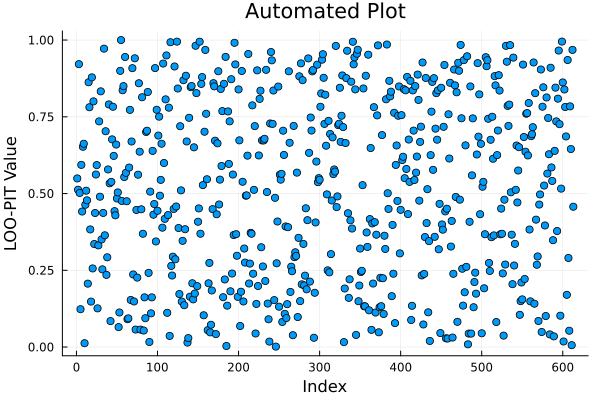

In [46]:
Plots.plot(loo_pit_y, xlabel="Index", ylabel="LOO-PIT Value", title="Automated Plot", legend=false, seriestype=:scatter)

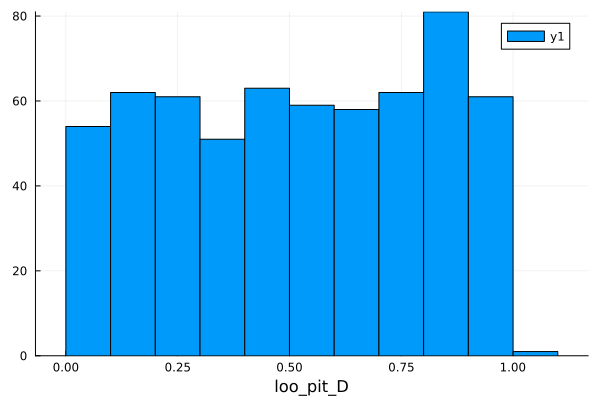

In [38]:
histogram(loo_pit_y, bins=10)

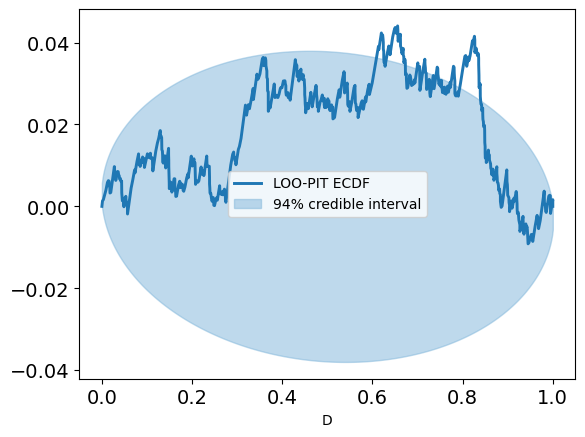

In [39]:
plot_loo_pit(idata; y=:D, ecdf=true)
gcf()

In [40]:
using DataFrames
using CairoMakie
using AlgebraOfGraphics
using AlgebraOfGraphics: density
using AlgebraOfGraphics: draw

In [41]:
df = DataFrame(idata.posterior)

Row,draw,chain,i,ωb,pred,ωc,ln10As,ns,h,τ,yₚ
,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,1,1,0.223835,9.58684,0.119942,0.30577,0.964092,0.674035,0.0575568,1.00344
2,2,1,1,0.223921,9.67829,0.121095,0.305647,0.960605,0.668995,0.0640583,0.995476
3,3,1,1,0.222076,9.65538,0.121823,0.305861,0.961049,0.664786,0.0611751,0.998352
4,4,1,1,0.224104,9.59443,0.120747,0.306015,0.964552,0.670304,0.0624251,0.99877
5,5,1,1,0.222545,9.67687,0.121,0.303753,0.95807,0.667924,0.0526125,0.99841
6,6,1,1,0.224363,9.51115,0.120449,0.304324,0.96687,0.67054,0.0545982,0.998796
7,7,1,1,0.222475,9.57368,0.12053,0.303847,0.961817,0.670229,0.0505505,1.00213
8,8,1,1,0.22403,9.67838,0.12343,0.304762,0.95913,0.661372,0.0504666,1.00192
9,9,1,1,0.22226,9.71076,0.121674,0.304349,0.958516,0.665367,0.0529684,0.998047


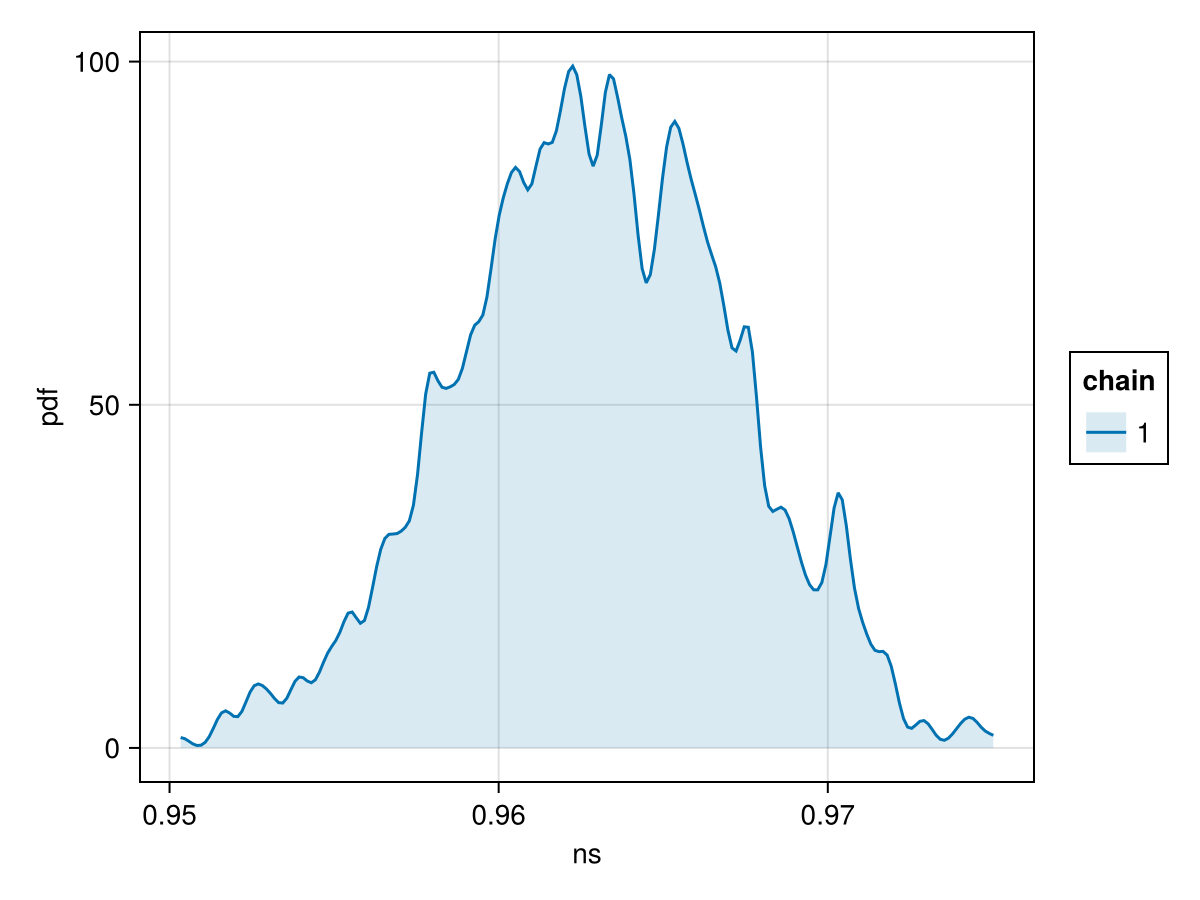

In [42]:
draw(
    data(idata.posterior) *
    mapping(:ns; color=:chain => nonnumeric) *
    density(),
)

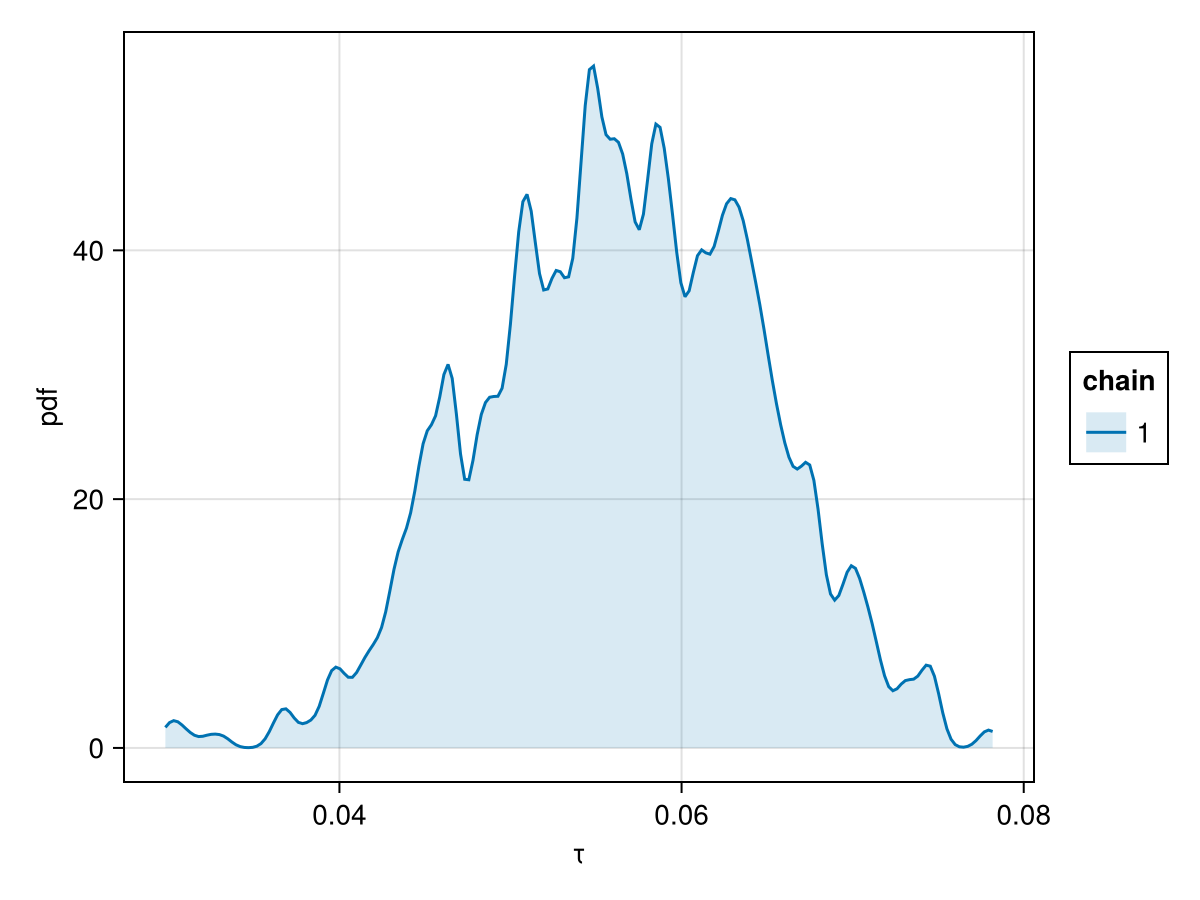

In [43]:
draw(
    data(idata.posterior) *
    mapping(:τ; color=:chain => nonnumeric) *
    density(),
)

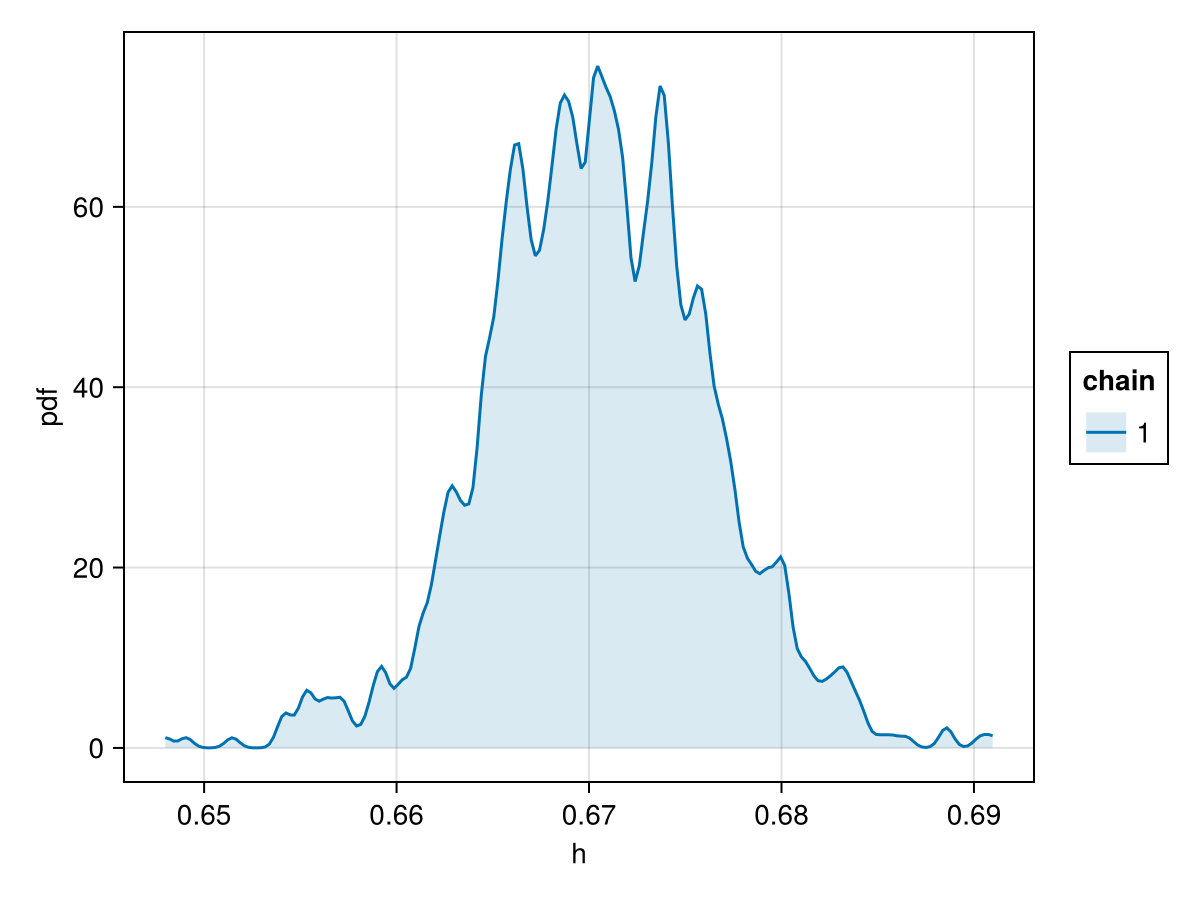

In [44]:
draw(
    data(idata.posterior) *
    mapping(:h; color=:chain => nonnumeric) *
    density(),
)